En este codigo buscamos determinar la longitud que deberan tener los brazos del MZI

In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# MMI (50/50 coupler)
def MMI():
    return (1/np.sqrt(2)) * np.array([[1, 1j],
                                      [1j, 1]])

# Phase shifter ahora depende de lambda
def phase_shifter(wl, delta_L, n_eff, lambda0):
    phi = 2 * np.pi * n_eff * delta_L * (1/wl - 1/lambda0)
    return np.array([[np.exp(1j * phi), 0],
                     [0, 1]])

# MZI físico
def MZI(wl, delta_L, n_eff, lambda0):
    U = MMI()
    P = phase_shifter(wl, delta_L, n_eff, lambda0)
    return U @ P @ U

In [35]:
# Parámetros
n_eff = 2.4
n_g = 4.0             # índice de grupo 
lambda0 = 1550e-9     # longitud de onda central
FSR = 40e-9          # 100 nm

delta_L = lambda0**2 / (n_g * FSR)

wl = np.linspace(1500e-9, 1600e-9, 500)

# Es necesario excitar una de las entradas para dejar de manejar matrices
# 2x2 y tener una relacion entrada salida del sistema
Ein = np.array([1, 0])

In [36]:
bar_port = [] # Al utilizar el metodo append lo que se generara es una lista
cross_port = []

for w in wl:
    H = MZI(w, delta_L, n_eff, lambda0)
    Eout = H @ Ein
    bar_port.append(Eout[0])
    cross_port.append(Eout[1])


p_bar_port = np.abs(bar_port)**2
p_cross_port = np.abs(cross_port)**2


# Convert to dB (avoid -inf by setting minimum value)
def to_db(power, floor=1e-4):
    # Compara elemento a elemento y devuelve el de mayor valor
    power = np.maximum(power, floor)
    return 10 * np.log10(power)

bar_port_db = to_db(p_bar_port)
cross_port_db = to_db(p_cross_port)


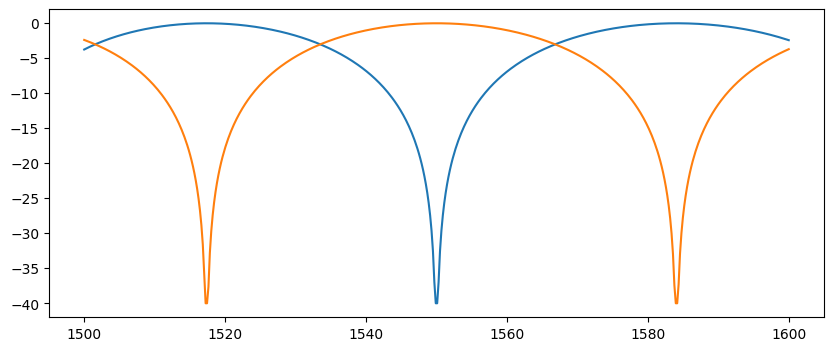

In [37]:
plt.figure(figsize=(10,4))
plt.plot(wl*1e9, bar_port_db, label="Bar Port (dB)")
plt.plot(wl*1e9, cross_port_db, label="Cross Port (dB)")

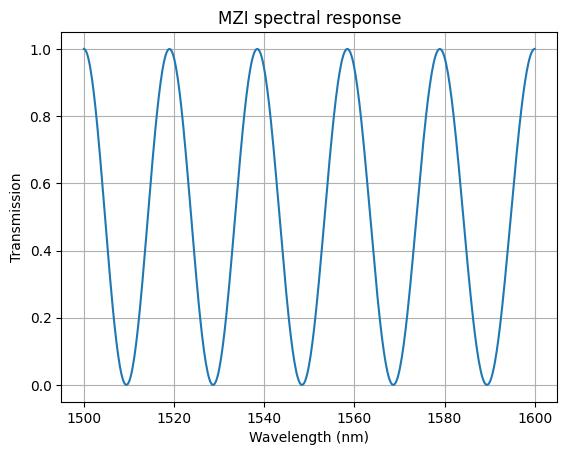

In [6]:
# Parámetros
n_eff = 2.4
delta_L = 50e-6  # 50 micras

wl = np.linspace(1500e-9, 1600e-9, 500)

T = []

for w in wl:
    H = MZI(w, delta_L, n_eff)
    T.append(np.abs(H[1,0])**2)  # salida cross

plt.plot(wl*1e9, T)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission")
plt.title("MZI spectral response")
plt.grid()
plt.show()